# SECTION 2: CNN-LSTM MODEL TRAINING

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Reshape, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, Adamax, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

# ========== SETUP ==========
SAMPLE_RATE = 22050
BATCH_SIZE = 32
NUM_CLASSES = 5

# ========== LOAD & PREPARE DATA ==========
X = np.load("X_hybrid_balanced.npy")
y = np.load("y_hybrid_balanced.npy")

X = X / np.max(X)
X = X[..., np.newaxis]
y_cat = to_categorical(y, num_classes=NUM_CLASSES)
class_names = ["belly pain", "burping", "discomfort", "hungry", "tired"]

# Function to allow split tuning
def split_data(split_ratio=(0.8, 0.1, 0.1)):
    X_temp, X_test, y_temp, y_test = train_test_split(X, y_cat, test_size=split_ratio[2], stratify=y, random_state=42)
    val_fraction = split_ratio[1] / (split_ratio[0] + split_ratio[1])
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_fraction, stratify=y_temp.argmax(1), random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# ========== ATTENTION LAYER ==========
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

# ========== MODEL ==========
def build_cnn_lstm_attention(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)
    x = Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = AttentionLayer()(x)
    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, output)

# ========== UNIVERSAL RUNNER FUNCTION ==========
def run_cnn_lstm_attention(optimizer_name="Adam", lr=0.001, epochs=60, patience=5, batch_size=16, split_ratio=(0.8, 0.1, 0.1), model_save_path="best_model.keras"):
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(split_ratio=split_ratio)
    
    model = build_cnn_lstm_attention(X_train.shape[1:], num_classes=NUM_CLASSES)

    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=lr)
    elif optimizer_name == "SGD":
        optimizer = SGD(learning_rate=lr)
    elif optimizer_name == "RMSprop":
        optimizer = RMSprop(learning_rate=lr)
    elif optimizer_name == "Adamax":
        optimizer = Adamax(learning_rate=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    checkpoint = ModelCheckpoint(model_save_path, monitor='val_accuracy', save_best_only=True, verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True)

    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=[early_stop, checkpoint], verbose=1)

    best_model = tf.keras.models.load_model(model_save_path, custom_objects={"AttentionLayer": AttentionLayer})

    train_loss, train_acc = best_model.evaluate(X_train, y_train, verbose=0)
    val_loss, val_acc = best_model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)

    print(f"\n🧪 Final Training Accuracy: {train_acc * 100:.2f}%")
    print(f"🧪 Final Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

    y_pred = best_model.predict(X_test).argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return train_acc, val_acc, test_acc


In [10]:
from keras.models import Sequential
from keras.layers import Conv2D, BatchNormalization, ReLU, MaxPooling2D, Dropout
from keras.layers import Reshape, LSTM, Dense
from keras.utils import plot_model

# === Define the CNN-LSTM model ===
model = Sequential()

# Convolutional layers
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=(39, 130, 1)))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(ReLU())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

# Reshape output to 3D for LSTM input
model.add(Reshape((model.output_shape[1], -1)))  # (batch_size, time_steps, features)

# LSTM layers
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64))

# Fully connected layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))  # 5 cry classes

# === Print model summary ===
model.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 39, 130, 32)       320       
                                                                 
 batch_normalization_8 (Batc  (None, 39, 130, 32)      128       
 hNormalization)                                                 
                                                                 
 re_lu_8 (ReLU)              (None, 39, 130, 32)       0         
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 19, 65, 32)       0         
 2D)                                                             
                                                                 
 dropout_12 (Dropout)        (None, 19, 65, 32)        0         
                                                                 
 conv2d_9 (Conv2D)           (None, 19, 65, 64)       


🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 80:10:10
Epoch 1/60
794/794 [==============================] - ETA: 0s - loss: 1.5359 - accuracy: 0.2752
Epoch 1: val_accuracy improved from -inf to 0.37406, saving model to best_model.keras
794/794 [==============================] - 403s 493ms/step - loss: 1.5359 - accuracy: 0.2752 - val_loss: 1.4048 - val_accuracy: 0.3741
Epoch 2/60
794/794 [==============================] - ETA: 0s - loss: 1.2814 - accuracy: 0.4403
Epoch 2: val_accuracy improved from 0.37406 to 0.48111, saving model to best_model.keras
794/794 [==============================] - 377s 474ms/step - loss: 1.2814 - accuracy: 0.4403 - val_loss: 1.1700 - val_accuracy: 0.4811
Epoch 3/60
794/794 [==============================] - ETA: 0s - loss: 0.9597 - accuracy: 0.5981
Epoch 3: val_accuracy improved from 0.48111 to 0.65113, saving model to best_model.keras
794/794 [==============================] - 367s 462ms/step - loss: 0.9597 - accuracy: 0.5981 - val_loss: 0.8576 -

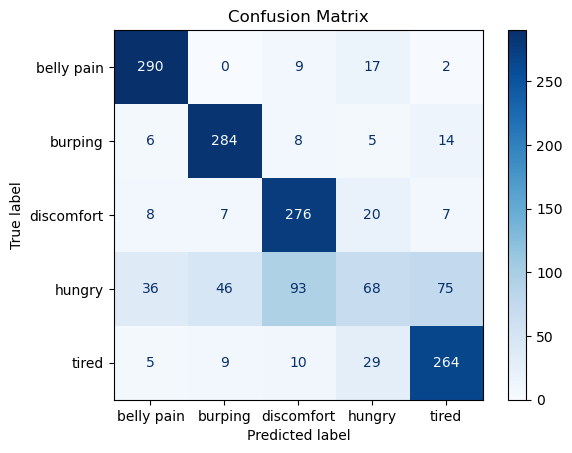

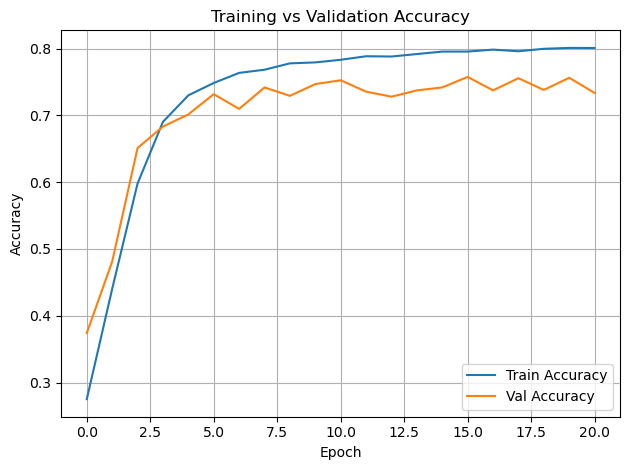

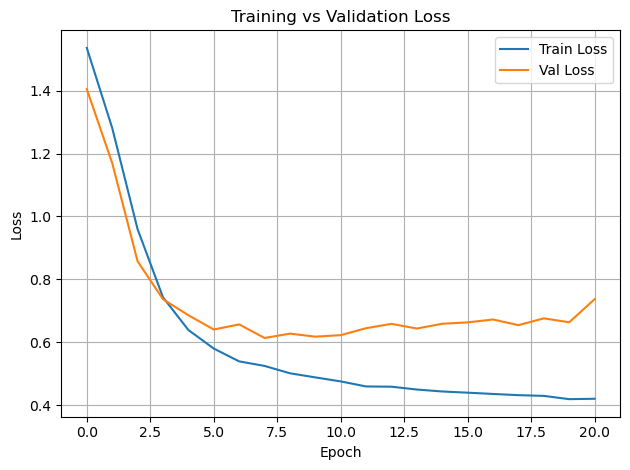

(0.8239924311637878, 0.757556676864624, 0.744332492351532)

In [2]:

print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam", 
    lr=0.001, 
    epochs=60,
    split_ratio=(0.8, 0.1, 0.1)
)



🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:15:15
Epoch 1/60
695/695 [==============================] - ETA: 0s - loss: 1.5723 - accuracy: 0.2497
Epoch 1: val_accuracy improved from -inf to 0.32662, saving model to best_model.keras
695/695 [==============================] - 405s 564ms/step - loss: 1.5723 - accuracy: 0.2497 - val_loss: 1.4582 - val_accuracy: 0.3266
Epoch 2/60
695/695 [==============================] - ETA: 0s - loss: 1.3844 - accuracy: 0.3731
Epoch 2: val_accuracy improved from 0.32662 to 0.40638, saving model to best_model.keras
695/695 [==============================] - 354s 510ms/step - loss: 1.3844 - accuracy: 0.3731 - val_loss: 1.3454 - val_accuracy: 0.4064
Epoch 3/60
695/695 [==============================] - ETA: 0s - loss: 1.1609 - accuracy: 0.5045
Epoch 3: val_accuracy improved from 0.40638 to 0.57767, saving model to best_model.keras
695/695 [==============================] - 430s 619ms/step - loss: 1.1609 - accuracy: 0.5045 - val_loss: 1.0022 -

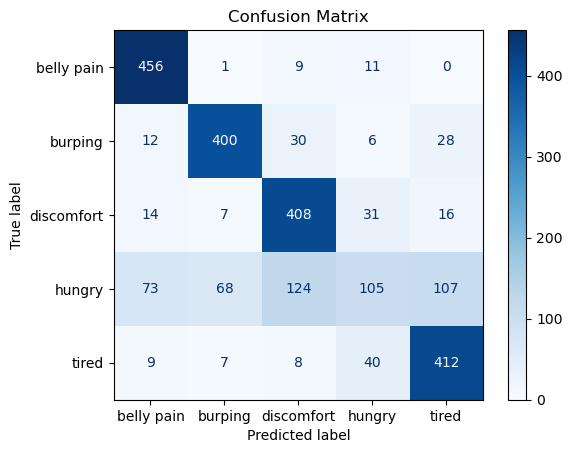

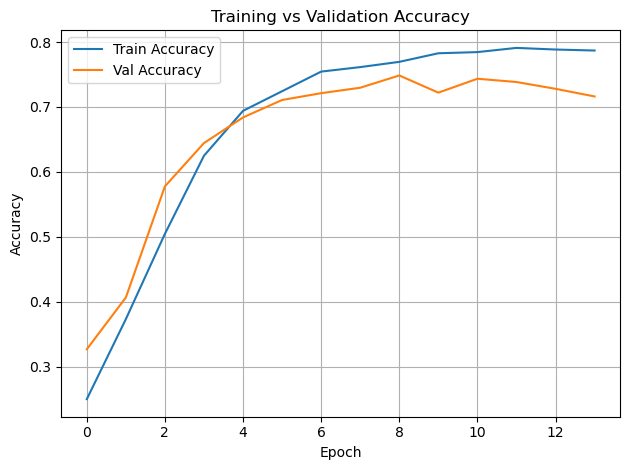

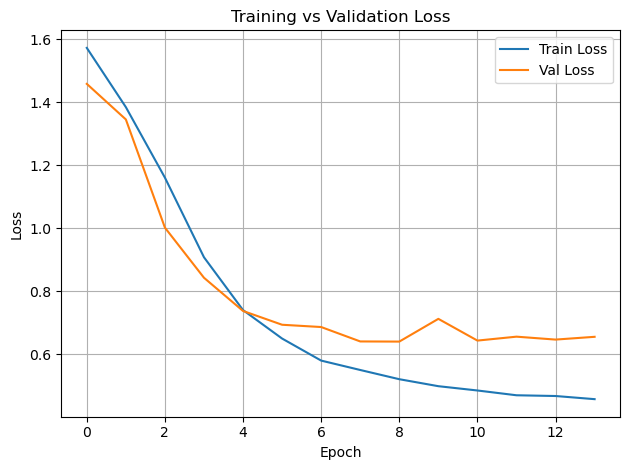

(0.8095538020133972, 0.7485306262969971, 0.7476910352706909)

In [3]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:15:15")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=60,
    split_ratio=(0.7, 0.15, 0.15)
)



🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:20:10
Epoch 1/60
348/348 [==============================] - ETA: 0s - loss: 1.5620 - accuracy: 0.2571
Epoch 1: val_accuracy improved from -inf to 0.31004, saving model to best_model.keras
348/348 [==============================] - 260s 718ms/step - loss: 1.5620 - accuracy: 0.2571 - val_loss: 1.4942 - val_accuracy: 0.3100
Epoch 2/60
348/348 [==============================] - ETA: 0s - loss: 1.4145 - accuracy: 0.3655
Epoch 2: val_accuracy improved from 0.31004 to 0.41360, saving model to best_model.keras
348/348 [==============================] - 227s 654ms/step - loss: 1.4145 - accuracy: 0.3655 - val_loss: 1.3359 - val_accuracy: 0.4136
Epoch 3/60
348/348 [==============================] - ETA: 0s - loss: 1.2246 - accuracy: 0.4804
Epoch 3: val_accuracy improved from 0.41360 to 0.52251, saving model to best_model.keras
348/348 [==============================] - 234s 671ms/step - loss: 1.2246 - accuracy: 0.4804 - val_loss: 1.1444 -

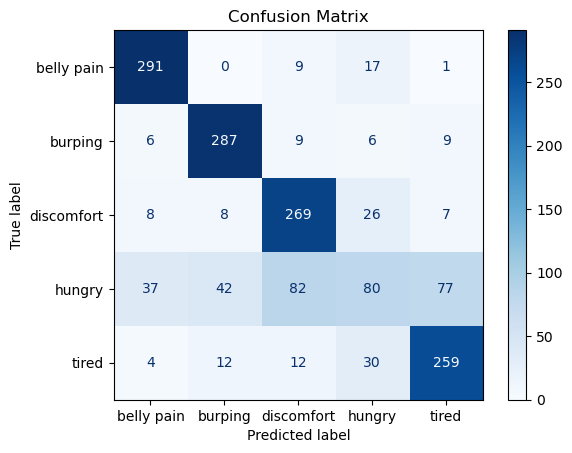

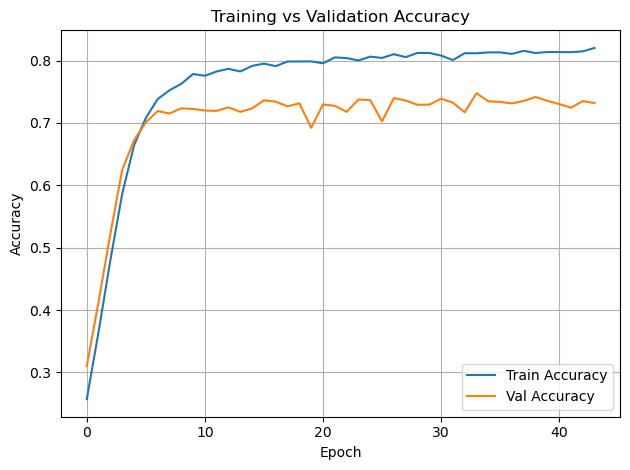

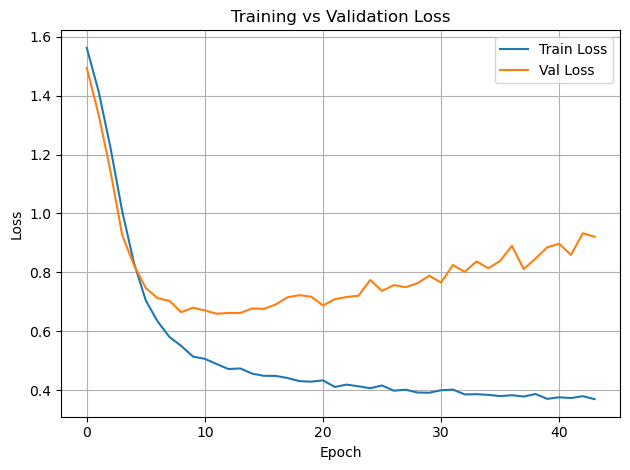

(0.8317588567733765, 0.7475606203079224, 0.74685138463974)

In [5]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 60 Epochs | Split 70:20:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.7, 0.20, 0.10)
)



🔬 Running: CNN-LSTM | SGD | 0.01 | 60 Epochs | Split 80:10:10
Epoch 1/60
397/397 [==============================] - ETA: 0s - loss: 1.6098 - accuracy: 0.1964
Epoch 1: val_accuracy improved from -inf to 0.19458, saving model to best_model.keras
397/397 [==============================] - 343s 848ms/step - loss: 1.6098 - accuracy: 0.1964 - val_loss: 1.6094 - val_accuracy: 0.1946
Epoch 2/60
397/397 [==============================] - ETA: 0s - loss: 1.6097 - accuracy: 0.2014
Epoch 2: val_accuracy improved from 0.19458 to 0.19962, saving model to best_model.keras
397/397 [==============================] - 335s 844ms/step - loss: 1.6097 - accuracy: 0.2014 - val_loss: 1.6095 - val_accuracy: 0.1996
Epoch 3/60
397/397 [==============================] - ETA: 0s - loss: 1.6097 - accuracy: 0.2003
Epoch 3: val_accuracy improved from 0.19962 to 0.21033, saving model to best_model.keras
397/397 [==============================] - 327s 824ms/step - loss: 1.6097 - accuracy: 0.2003 - val_loss: 1.6094 - v

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


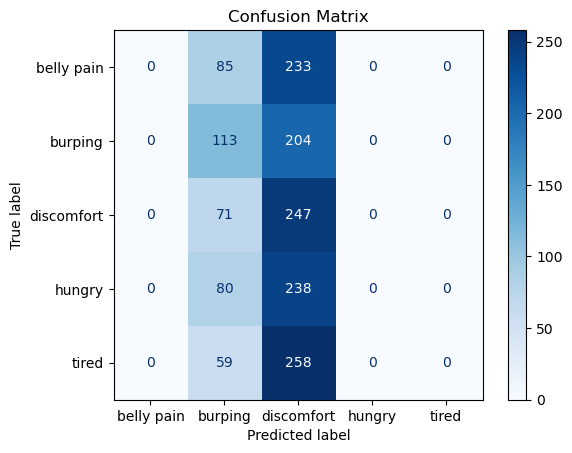

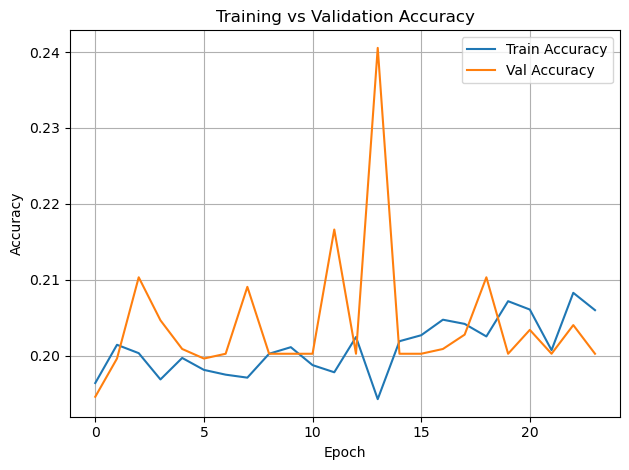

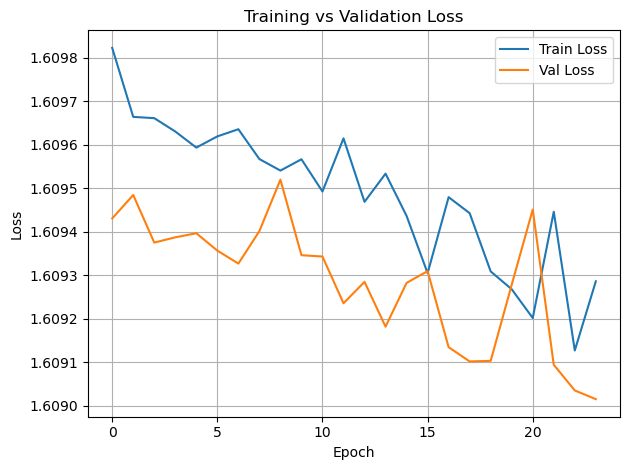

(0.22410264611244202, 0.24055415391921997, 0.22670024633407593)

In [6]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | SGD | 0.01 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="SGD",
    lr=0.01,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)



🔬 Running: CNN-LSTM | RMSprop | 0.001 | 60 Epochs | Split 80:10:10
Epoch 1/60
397/397 [==============================] - ETA: 0s - loss: 1.6076 - accuracy: 0.2135
Epoch 1: val_accuracy improved from -inf to 0.26385, saving model to best_model.keras
397/397 [==============================] - 265s 653ms/step - loss: 1.6076 - accuracy: 0.2135 - val_loss: 1.5877 - val_accuracy: 0.2639
Epoch 2/60
397/397 [==============================] - ETA: 0s - loss: 1.5555 - accuracy: 0.2846
Epoch 2: val_accuracy improved from 0.26385 to 0.31675, saving model to best_model.keras
397/397 [==============================] - 251s 633ms/step - loss: 1.5555 - accuracy: 0.2846 - val_loss: 1.4879 - val_accuracy: 0.3168
Epoch 3/60
397/397 [==============================] - ETA: 0s - loss: 1.4481 - accuracy: 0.3500
Epoch 3: val_accuracy improved from 0.31675 to 0.39673, saving model to best_model.keras
397/397 [==============================] - 261s 657ms/step - loss: 1.4481 - accuracy: 0.3500 - val_loss: 1.361

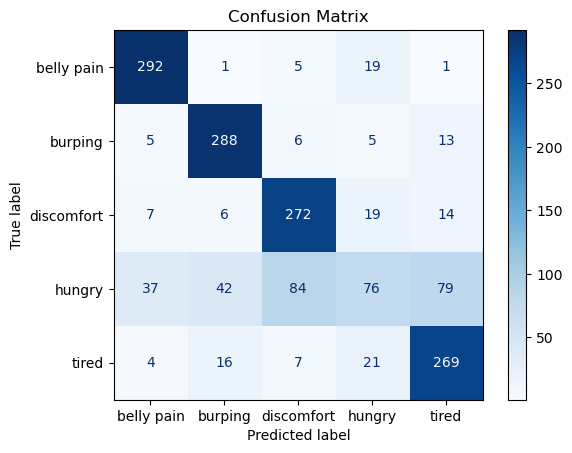

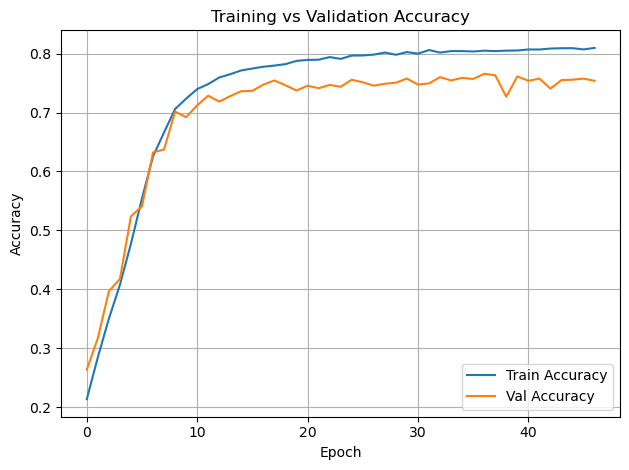

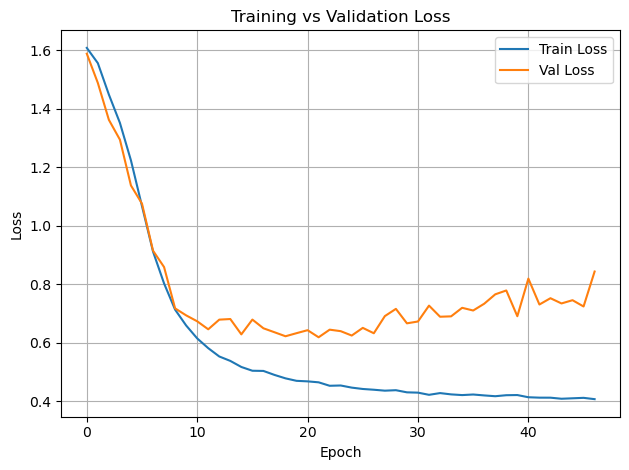

(0.823205292224884, 0.7657430768013, 0.753778338432312)

In [7]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | RMSprop | 0.001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="RMSprop",
    lr=0.001,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)



🔬 Running: CNN-LSTM |RMSprop | 0.0005 | 60 Epochs | Split 80:10:10
Epoch 1/60
397/397 [==============================] - ETA: 0s - loss: 1.6078 - accuracy: 0.2162
Epoch 1: val_accuracy improved from -inf to 0.21662, saving model to best_model.keras
397/397 [==============================] - 442s 1s/step - loss: 1.6078 - accuracy: 0.2162 - val_loss: 1.6034 - val_accuracy: 0.2166
Epoch 2/60
397/397 [==============================] - ETA: 0s - loss: 1.5727 - accuracy: 0.2742
Epoch 2: val_accuracy improved from 0.21662 to 0.31675, saving model to best_model.keras
397/397 [==============================] - 408s 1s/step - loss: 1.5727 - accuracy: 0.2742 - val_loss: 1.5277 - val_accuracy: 0.3168
Epoch 3/60
397/397 [==============================] - ETA: 0s - loss: 1.5046 - accuracy: 0.3043
Epoch 3: val_accuracy improved from 0.31675 to 0.32305, saving model to best_model.keras
397/397 [==============================] - 383s 964ms/step - loss: 1.5046 - accuracy: 0.3043 - val_loss: 1.4682 - va

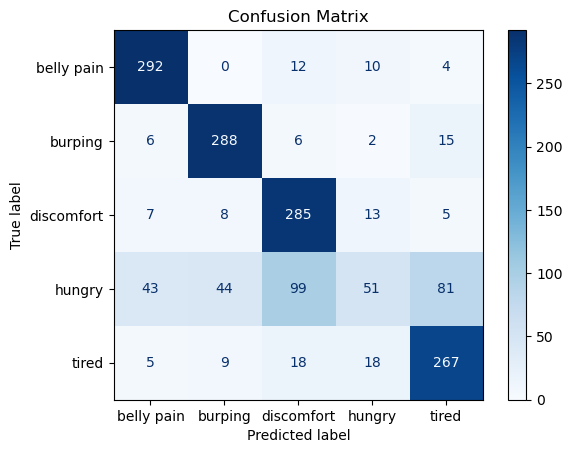

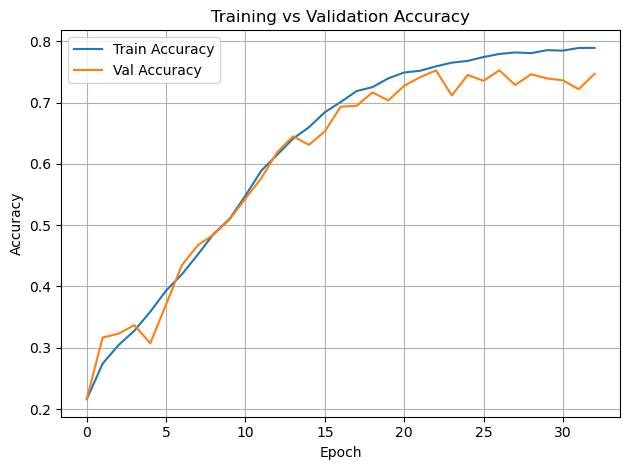

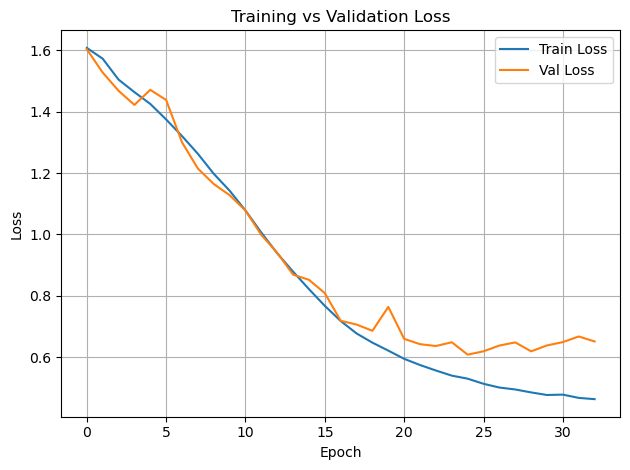

(0.7968356609344482, 0.752518892288208, 0.744962215423584)

In [9]:
print("\n==========================")
print("🔬 Running: CNN-LSTM |RMSprop | 0.0005 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="RMSprop",
    lr=0.0005,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM |Adam | 0.0005 | 60 Epochs | Split 80:10:10
Epoch 1/60
397/397 [==============================] - ETA: 0s - loss: 1.5806 - accuracy: 0.2490
Epoch 1: val_accuracy improved from -inf to 0.30479, saving model to best_model.keras
397/397 [==============================] - 266s 651ms/step - loss: 1.5806 - accuracy: 0.2490 - val_loss: 1.5015 - val_accuracy: 0.3048
Epoch 2/60
397/397 [==============================] - ETA: 0s - loss: 1.4719 - accuracy: 0.3324
Epoch 2: val_accuracy improved from 0.30479 to 0.36965, saving model to best_model.keras
397/397 [==============================] - 248s 625ms/step - loss: 1.4719 - accuracy: 0.3324 - val_loss: 1.4006 - val_accuracy: 0.3696
Epoch 3/60
397/397 [==============================] - ETA: 0s - loss: 1.3418 - accuracy: 0.4107
Epoch 3: val_accuracy improved from 0.36965 to 0.43073, saving model to best_model.keras
397/397 [==============================] - 245s 616ms/step - loss: 1.3418 - accuracy: 0.4107 - val_loss: 1.2663 -

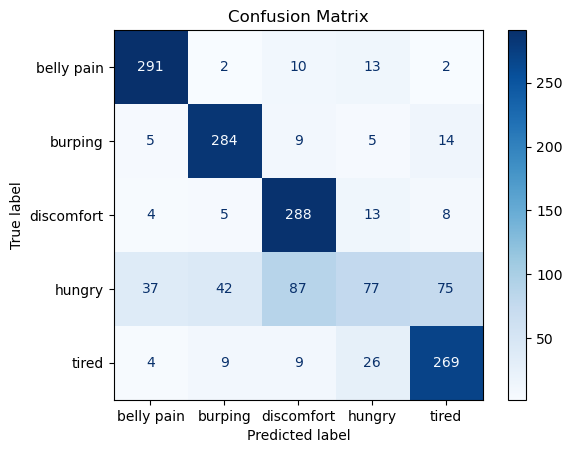

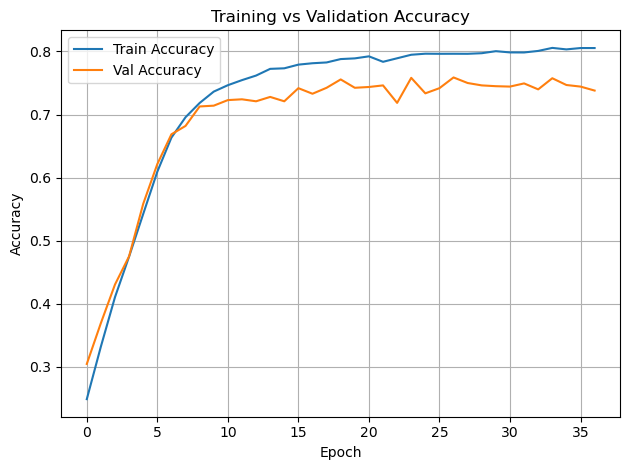

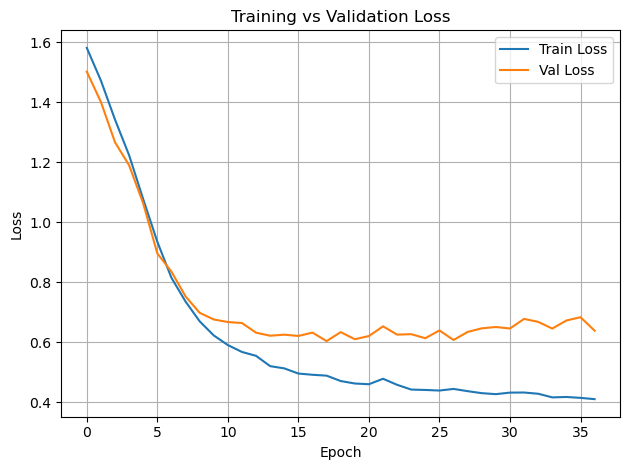

(0.8189546465873718, 0.758816123008728, 0.761335015296936)

In [4]:
print("\n==========================")
print("🔬 Running: CNN-LSTM |Adam | 0.0005 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.0005,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM | RMSprop | 0.0001 | 60 Epochs | Split 80:10:10
Epoch 1/60
397/397 [==============================] - ETA: 0s - loss: 1.6094 - accuracy: 0.1984
Epoch 1: val_accuracy improved from -inf to 0.19207, saving model to best_model.keras
397/397 [==============================] - 271s 666ms/step - loss: 1.6094 - accuracy: 0.1984 - val_loss: 1.6089 - val_accuracy: 0.1921
Epoch 2/60
397/397 [==============================] - ETA: 0s - loss: 1.6083 - accuracy: 0.2206
Epoch 2: val_accuracy improved from 0.19207 to 0.23174, saving model to best_model.keras
397/397 [==============================] - 256s 644ms/step - loss: 1.6083 - accuracy: 0.2206 - val_loss: 1.6073 - val_accuracy: 0.2317
Epoch 3/60
397/397 [==============================] - ETA: 0s - loss: 1.6034 - accuracy: 0.2395
Epoch 3: val_accuracy improved from 0.23174 to 0.26637, saving model to best_model.keras
397/397 [==============================] - 253s 636ms/step - loss: 1.6034 - accuracy: 0.2395 - val_loss: 1.59

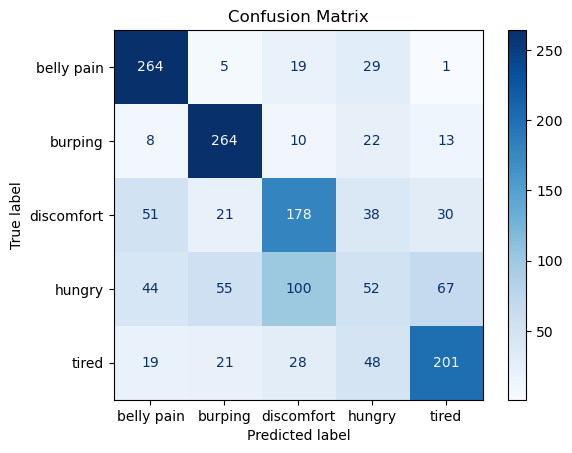

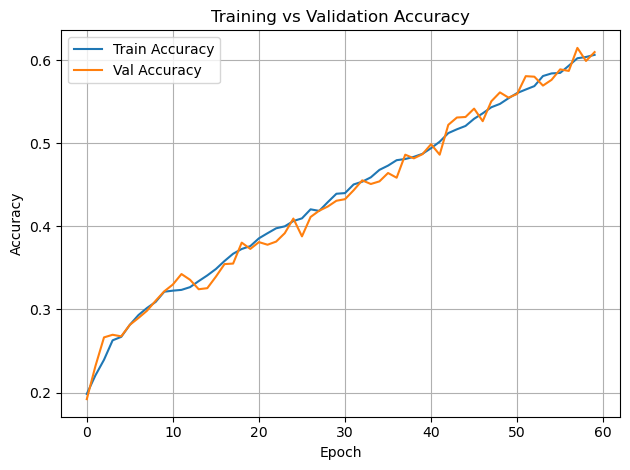

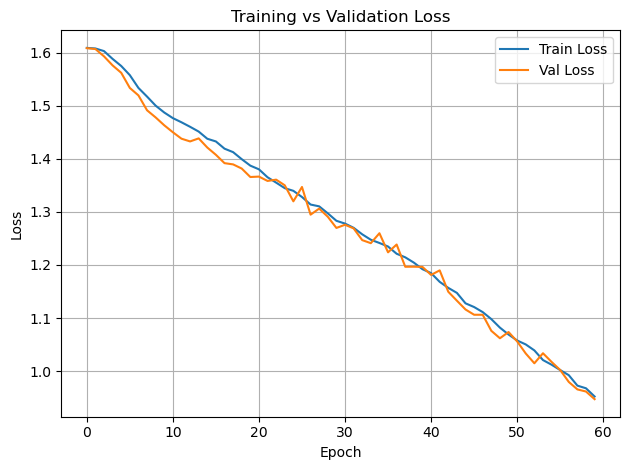

(0.6628620624542236, 0.6146095991134644, 0.6039043068885803)

In [10]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | RMSprop | 0.0001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="RMSprop",
    lr=0.0001,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM | Adam | 0.0001 | 60 Epochs | Split 80:10:10
Epoch 1/60
397/397 [==============================] - ETA: 0s - loss: 1.6089 - accuracy: 0.2002
Epoch 1: val_accuracy improved from -inf to 0.26134, saving model to best_model.keras
397/397 [==============================] - 262s 644ms/step - loss: 1.6089 - accuracy: 0.2002 - val_loss: 1.6064 - val_accuracy: 0.2613
Epoch 2/60
397/397 [==============================] - ETA: 0s - loss: 1.5829 - accuracy: 0.2595
Epoch 2: val_accuracy improved from 0.26134 to 0.26511, saving model to best_model.keras
397/397 [==============================] - 244s 615ms/step - loss: 1.5829 - accuracy: 0.2595 - val_loss: 1.5479 - val_accuracy: 0.2651
Epoch 3/60
397/397 [==============================] - ETA: 0s - loss: 1.5234 - accuracy: 0.3013
Epoch 3: val_accuracy improved from 0.26511 to 0.31171, saving model to best_model.keras
397/397 [==============================] - 243s 613ms/step - loss: 1.5234 - accuracy: 0.3013 - val_loss: 1.4944 

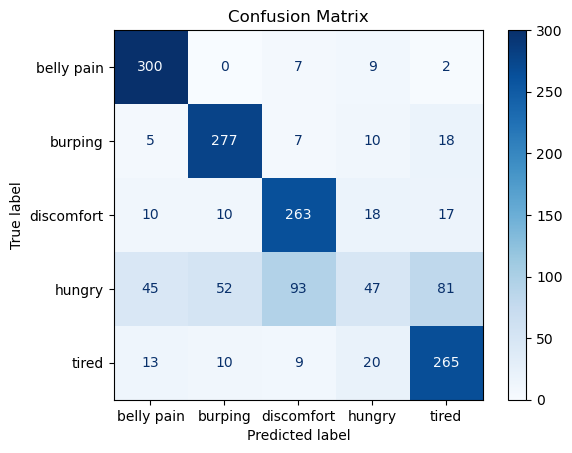

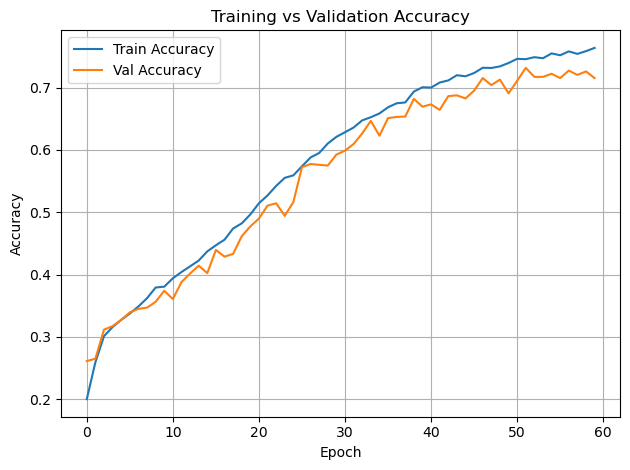

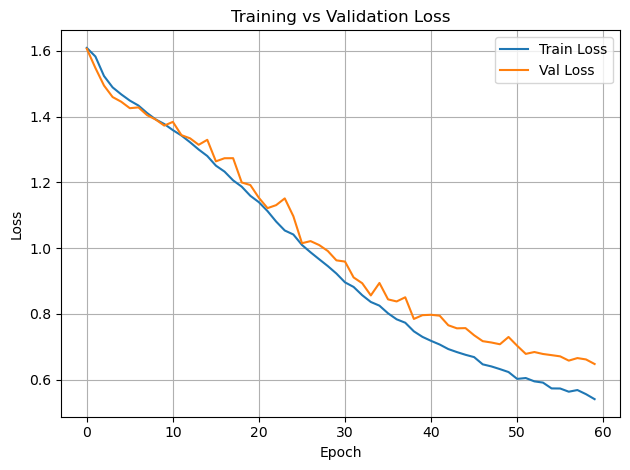

(0.7772355079650879, 0.7317380309104919, 0.7254408001899719)

In [5]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.0001 | 60 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.0001,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM | RMSprop | 0.001 | 20 Epochs | Split 80:10:10
Epoch 1/20
397/397 [==============================] - ETA: 0s - loss: 1.6084 - accuracy: 0.2045
Epoch 1: val_accuracy improved from -inf to 0.26259, saving model to best_model.keras
397/397 [==============================] - 348s 856ms/step - loss: 1.6084 - accuracy: 0.2045 - val_loss: 1.5926 - val_accuracy: 0.2626
Epoch 2/20
397/397 [==============================] - ETA: 0s - loss: 1.5583 - accuracy: 0.2817
Epoch 2: val_accuracy improved from 0.26259 to 0.31738, saving model to best_model.keras
397/397 [==============================] - 262s 661ms/step - loss: 1.5583 - accuracy: 0.2817 - val_loss: 1.5026 - val_accuracy: 0.3174
Epoch 3/20
397/397 [==============================] - ETA: 0s - loss: 1.4525 - accuracy: 0.3469
Epoch 3: val_accuracy improved from 0.31738 to 0.38602, saving model to best_model.keras
397/397 [==============================] - 256s 646ms/step - loss: 1.4525 - accuracy: 0.3469 - val_loss: 1.379

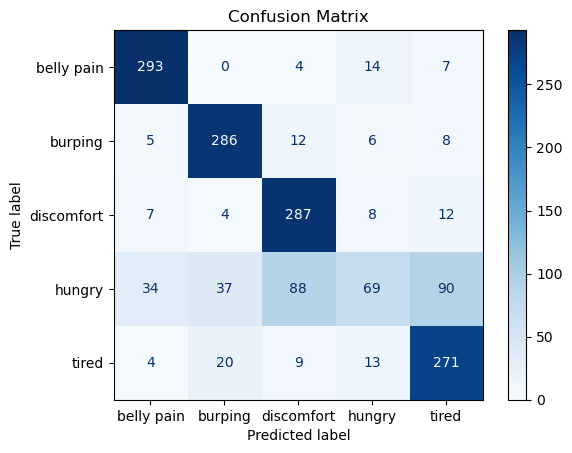

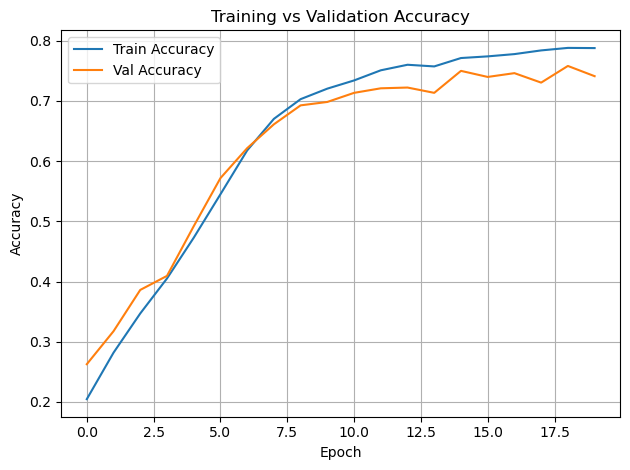

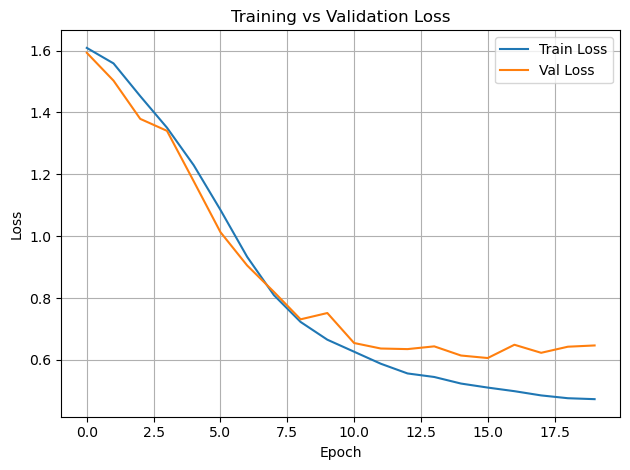

(0.8113979697227478, 0.758186399936676, 0.75944584608078)

In [2]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | RMSprop | 0.001 | 20 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="RMSprop",
    lr=0.001,
    epochs=20,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM | Adam | 0.001 | 20 Epochs | Split 80:10:10
Epoch 1/20
397/397 [==============================] - ETA: 0s - loss: 1.5555 - accuracy: 0.2638
Epoch 1: val_accuracy improved from -inf to 0.34824, saving model to best_model.keras
397/397 [==============================] - 259s 636ms/step - loss: 1.5555 - accuracy: 0.2638 - val_loss: 1.4362 - val_accuracy: 0.3482
Epoch 2/20
397/397 [==============================] - ETA: 0s - loss: 1.3442 - accuracy: 0.4078
Epoch 2: val_accuracy improved from 0.34824 to 0.46977, saving model to best_model.keras
397/397 [==============================] - 246s 620ms/step - loss: 1.3442 - accuracy: 0.4078 - val_loss: 1.2200 - val_accuracy: 0.4698
Epoch 3/20
397/397 [==============================] - ETA: 0s - loss: 1.1110 - accuracy: 0.5357
Epoch 3: val_accuracy improved from 0.46977 to 0.59635, saving model to best_model.keras
397/397 [==============================] - 243s 613ms/step - loss: 1.1110 - accuracy: 0.5357 - val_loss: 0.9889 -

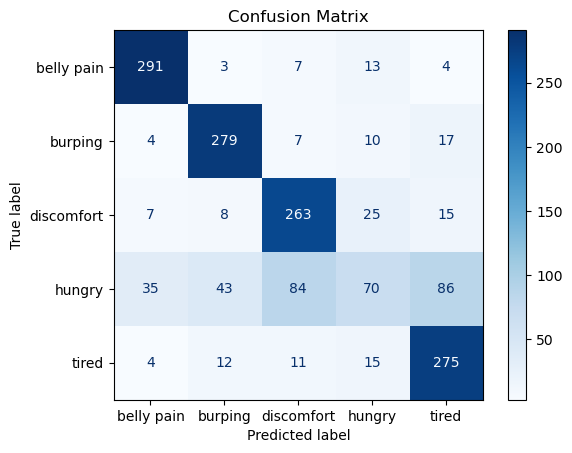

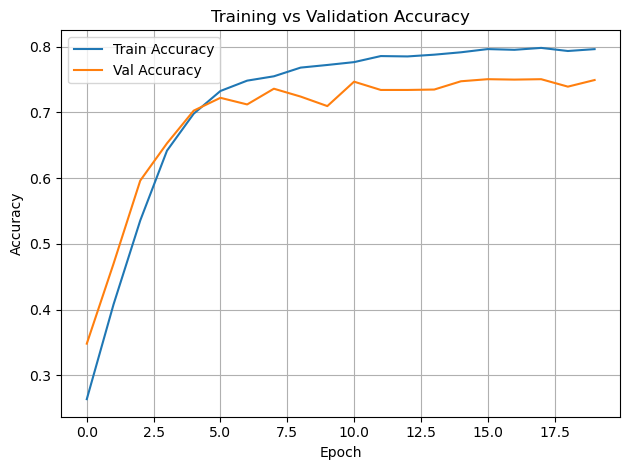

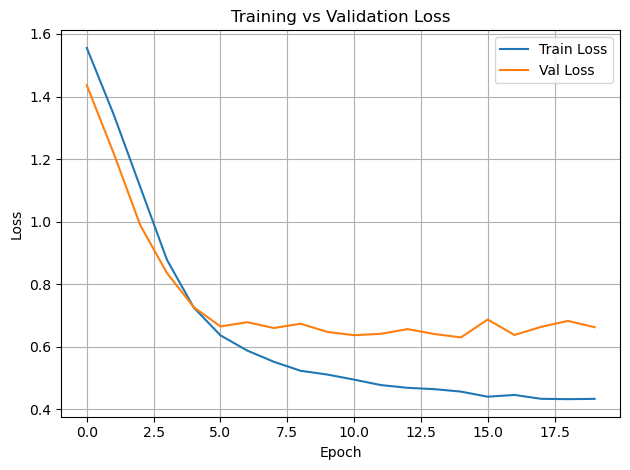

(0.8166719079017639, 0.750629723072052, 0.741813600063324)

In [6]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 20 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=20,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM | RMSprop | 0.001 | 40 Epochs | Split 80:10:10
Epoch 1/40
397/397 [==============================] - ETA: 0s - loss: 1.6075 - accuracy: 0.2137
Epoch 1: val_accuracy improved from -inf to 0.28904, saving model to best_model.keras
397/397 [==============================] - 289s 708ms/step - loss: 1.6075 - accuracy: 0.2137 - val_loss: 1.5735 - val_accuracy: 0.2890
Epoch 2/40
397/397 [==============================] - ETA: 0s - loss: 1.5477 - accuracy: 0.2856
Epoch 2: val_accuracy improved from 0.28904 to 0.31675, saving model to best_model.keras
397/397 [==============================] - 252s 636ms/step - loss: 1.5477 - accuracy: 0.2856 - val_loss: 1.4675 - val_accuracy: 0.3168
Epoch 3/40
397/397 [==============================] - ETA: 0s - loss: 1.4600 - accuracy: 0.3367
Epoch 3: val_accuracy improved from 0.31675 to 0.35957, saving model to best_model.keras
397/397 [==============================] - 249s 628ms/step - loss: 1.4600 - accuracy: 0.3367 - val_loss: 1.402

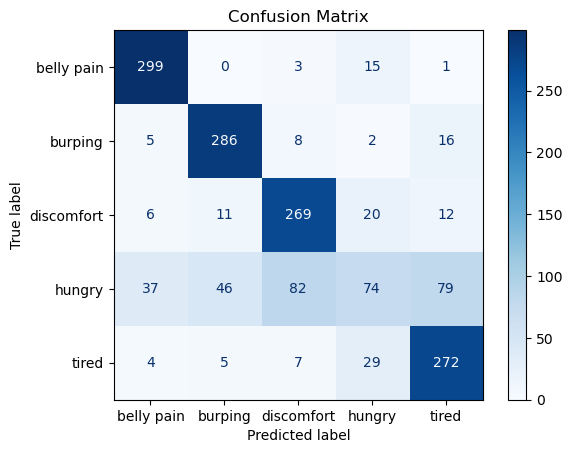

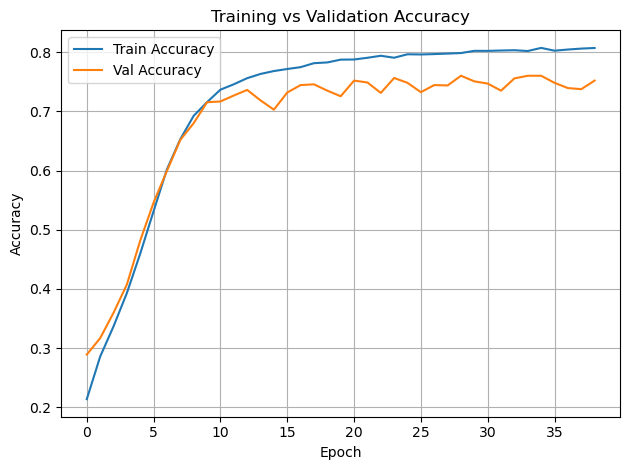

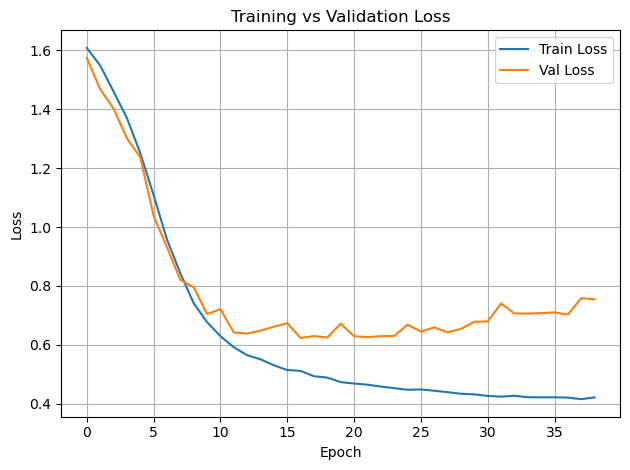

(0.8202928304672241, 0.760075569152832, 0.755667507648468)

In [3]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | RMSprop | 0.001 | 40 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="RMSprop",
    lr=0.001,
    epochs=40,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)


🔬 Running: CNN-LSTM | Adam | 0.001 | 40 Epochs | Split 80:10:10
Epoch 1/40
397/397 [==============================] - ETA: 0s - loss: 1.5690 - accuracy: 0.2532
Epoch 1: val_accuracy improved from -inf to 0.30668, saving model to best_model.keras
397/397 [==============================] - 276s 668ms/step - loss: 1.5690 - accuracy: 0.2532 - val_loss: 1.4430 - val_accuracy: 0.3067
Epoch 2/40
397/397 [==============================] - ETA: 0s - loss: 1.3712 - accuracy: 0.3915
Epoch 2: val_accuracy improved from 0.30668 to 0.47292, saving model to best_model.keras
397/397 [==============================] - 252s 634ms/step - loss: 1.3712 - accuracy: 0.3915 - val_loss: 1.2318 - val_accuracy: 0.4729
Epoch 3/40
397/397 [==============================] - ETA: 0s - loss: 1.1296 - accuracy: 0.5293
Epoch 3: val_accuracy improved from 0.47292 to 0.58186, saving model to best_model.keras
397/397 [==============================] - 258s 650ms/step - loss: 1.1296 - accuracy: 0.5293 - val_loss: 0.9936 -

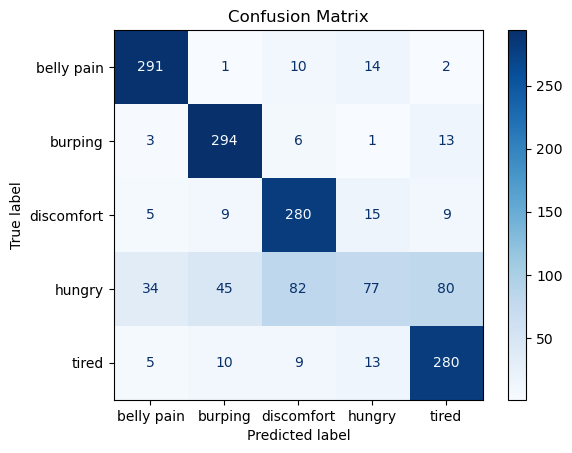

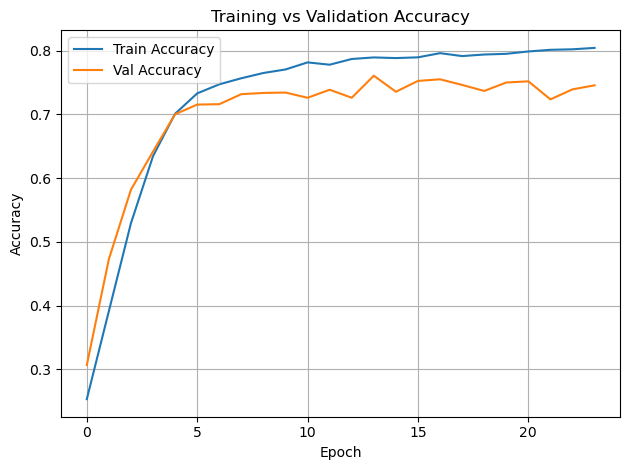

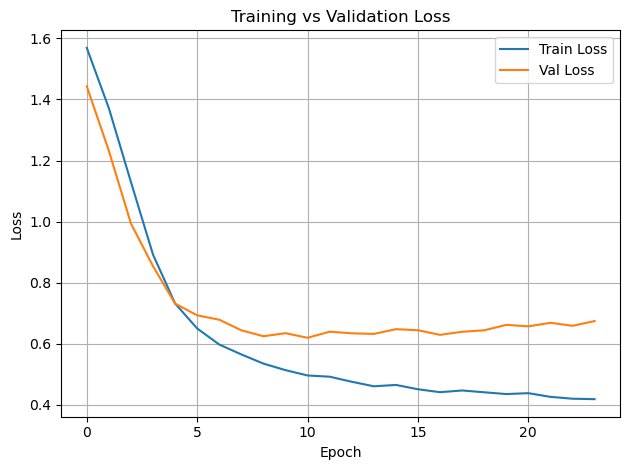

(0.8151763081550598, 0.760705292224884, 0.7695214152336121)

In [8]:
print("\n==========================")
print("🔬 Running: CNN-LSTM | Adam | 0.001 | 40 Epochs | Split 80:10:10")
print("==========================")
run_cnn_lstm_attention(
    optimizer_name="Adam",
    lr=0.001,
    epochs=40,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10)
)

# to save the best model experiment

Epoch 1/60
397/397 [==============================] - ETA: 0s - loss: 1.6094 - accuracy: 0.2043
Epoch 1: val_accuracy improved from -inf to 0.25693, saving model to best_model.keras
397/397 [==============================] - 348s 856ms/step - loss: 1.6094 - accuracy: 0.2043 - val_loss: 1.6013 - val_accuracy: 0.2569
Epoch 2/60
397/397 [==============================] - ETA: 0s - loss: 1.5570 - accuracy: 0.2821
Epoch 2: val_accuracy improved from 0.25693 to 0.31108, saving model to best_model.keras
397/397 [==============================] - 333s 838ms/step - loss: 1.5570 - accuracy: 0.2821 - val_loss: 1.4739 - val_accuracy: 0.3111
Epoch 3/60
397/397 [==============================] - ETA: 0s - loss: 1.4493 - accuracy: 0.3489
Epoch 3: val_accuracy improved from 0.31108 to 0.38224, saving model to best_model.keras
397/397 [==============================] - 332s 837ms/step - loss: 1.4493 - accuracy: 0.3489 - val_loss: 1.3872 - val_accuracy: 0.3822
Epoch 4/60
397/397 [=======================

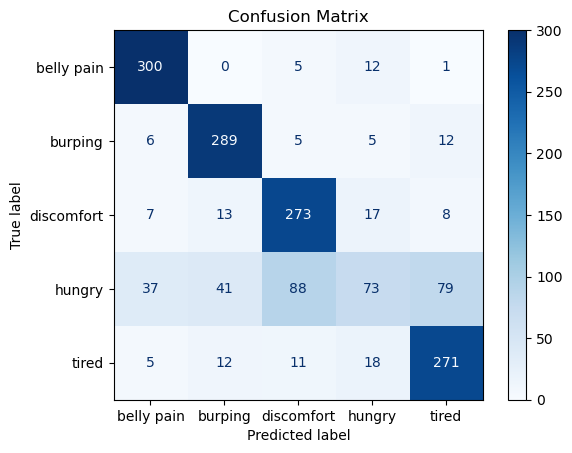

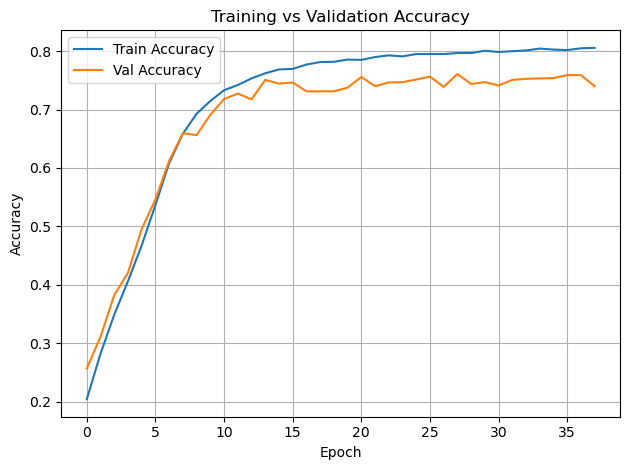

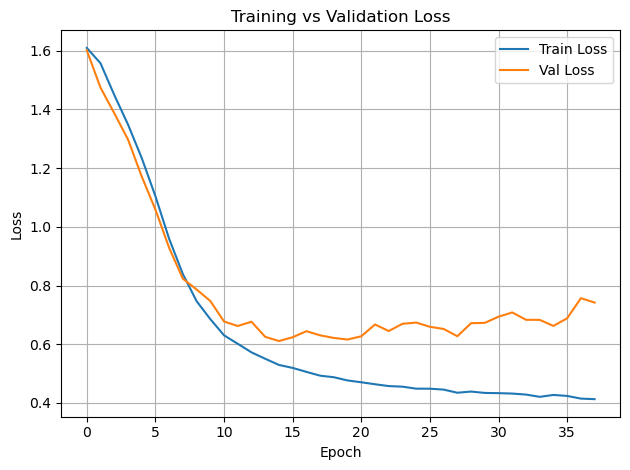

(0.8196631073951721, 0.760705292224884, 0.75944584608078)

In [3]:
run_cnn_lstm_attention(optimizer_name="RMSprop",
    lr=0.001,
    epochs=60,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10),
    model_save_path="best_model.keras") #paste back the one i want

Epoch 1/20
397/397 [==============================] - ETA: 0s - loss: 1.5626 - accuracy: 0.2575
Epoch 1: val_accuracy improved from -inf to 0.31801, saving model to best_model.keras
397/397 [==============================] - 379s 923ms/step - loss: 1.5626 - accuracy: 0.2575 - val_loss: 1.4588 - val_accuracy: 0.3180
Epoch 2/20
397/397 [==============================] - ETA: 0s - loss: 1.3840 - accuracy: 0.3789
Epoch 2: val_accuracy improved from 0.31801 to 0.44270, saving model to best_model.keras
397/397 [==============================] - 353s 890ms/step - loss: 1.3840 - accuracy: 0.3789 - val_loss: 1.2791 - val_accuracy: 0.4427
Epoch 3/20
397/397 [==============================] - ETA: 0s - loss: 1.1732 - accuracy: 0.5060
Epoch 3: val_accuracy improved from 0.44270 to 0.54408, saving model to best_model.keras
397/397 [==============================] - 357s 900ms/step - loss: 1.1732 - accuracy: 0.5060 - val_loss: 1.0610 - val_accuracy: 0.5441
Epoch 4/20
397/397 [=======================

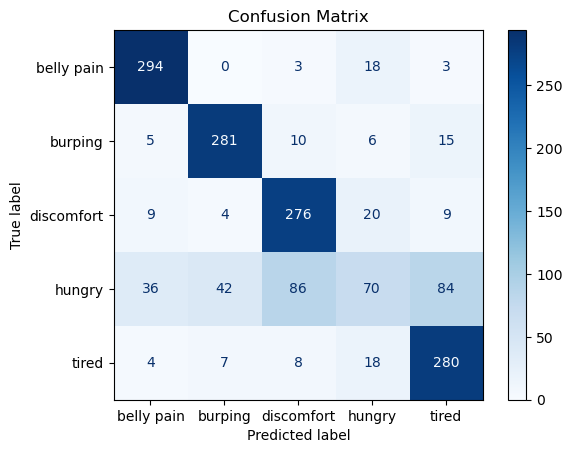

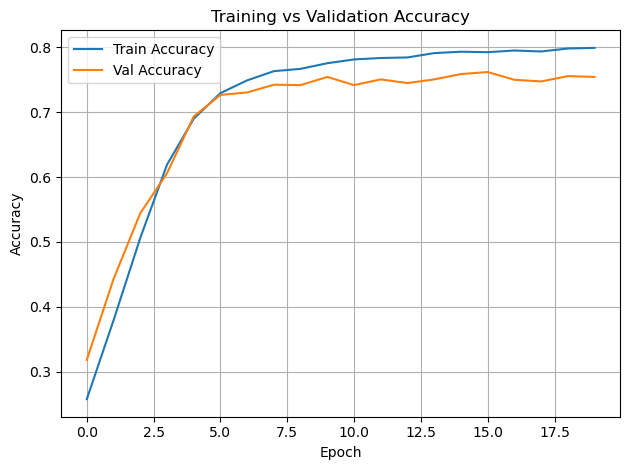

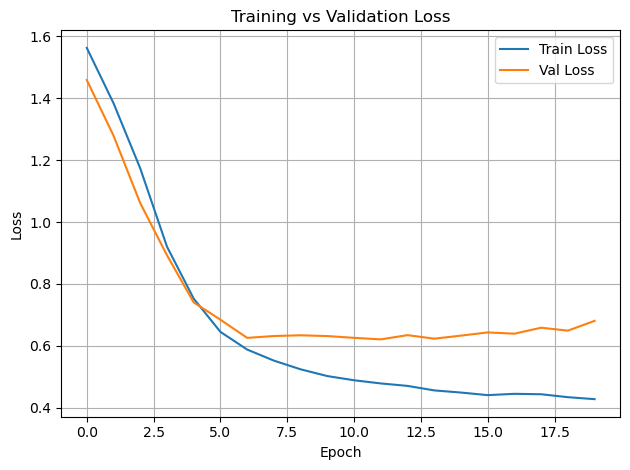

(0.818167507648468, 0.761964738368988, 0.75629723072052)

In [2]:
run_cnn_lstm_attention(optimizer_name="Adam",
    lr=0.001,
    epochs=20,
    batch_size=32,
    patience=10,
    split_ratio=(0.8, 0.10, 0.10),
    model_save_path="best_model.keras") #paste back the one i want